<div style="border: 2px solid white; padding: 15px; border-radius: 10px;">



<h2 align="center">Swarm Algorithms - vs - Deep Learning - on - MNIST</h2>  


</div>


c:\Users\Adarsh Ranjan\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Adarsh Ranjan\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Adarsh Ranjan\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at

Performance Metrics (Mean ± Std):

Adjusted Rand Index:
KMEANS: 0.9542 ± 0.0391
PSO: 0.9547 ± 0.0379
GWO: 0.7009 ± 0.0558

Normalized Mutual Info:
KMEANS: 0.9076 ± 0.0634
PSO: 0.9081 ± 0.0618
GWO: 0.6024 ± 0.0544

Dice Coefficient:
KMEANS: 0.9677 ± 0.0285
PSO: 0.9679 ± 0.0279
GWO: 0.7974 ± 0.0485


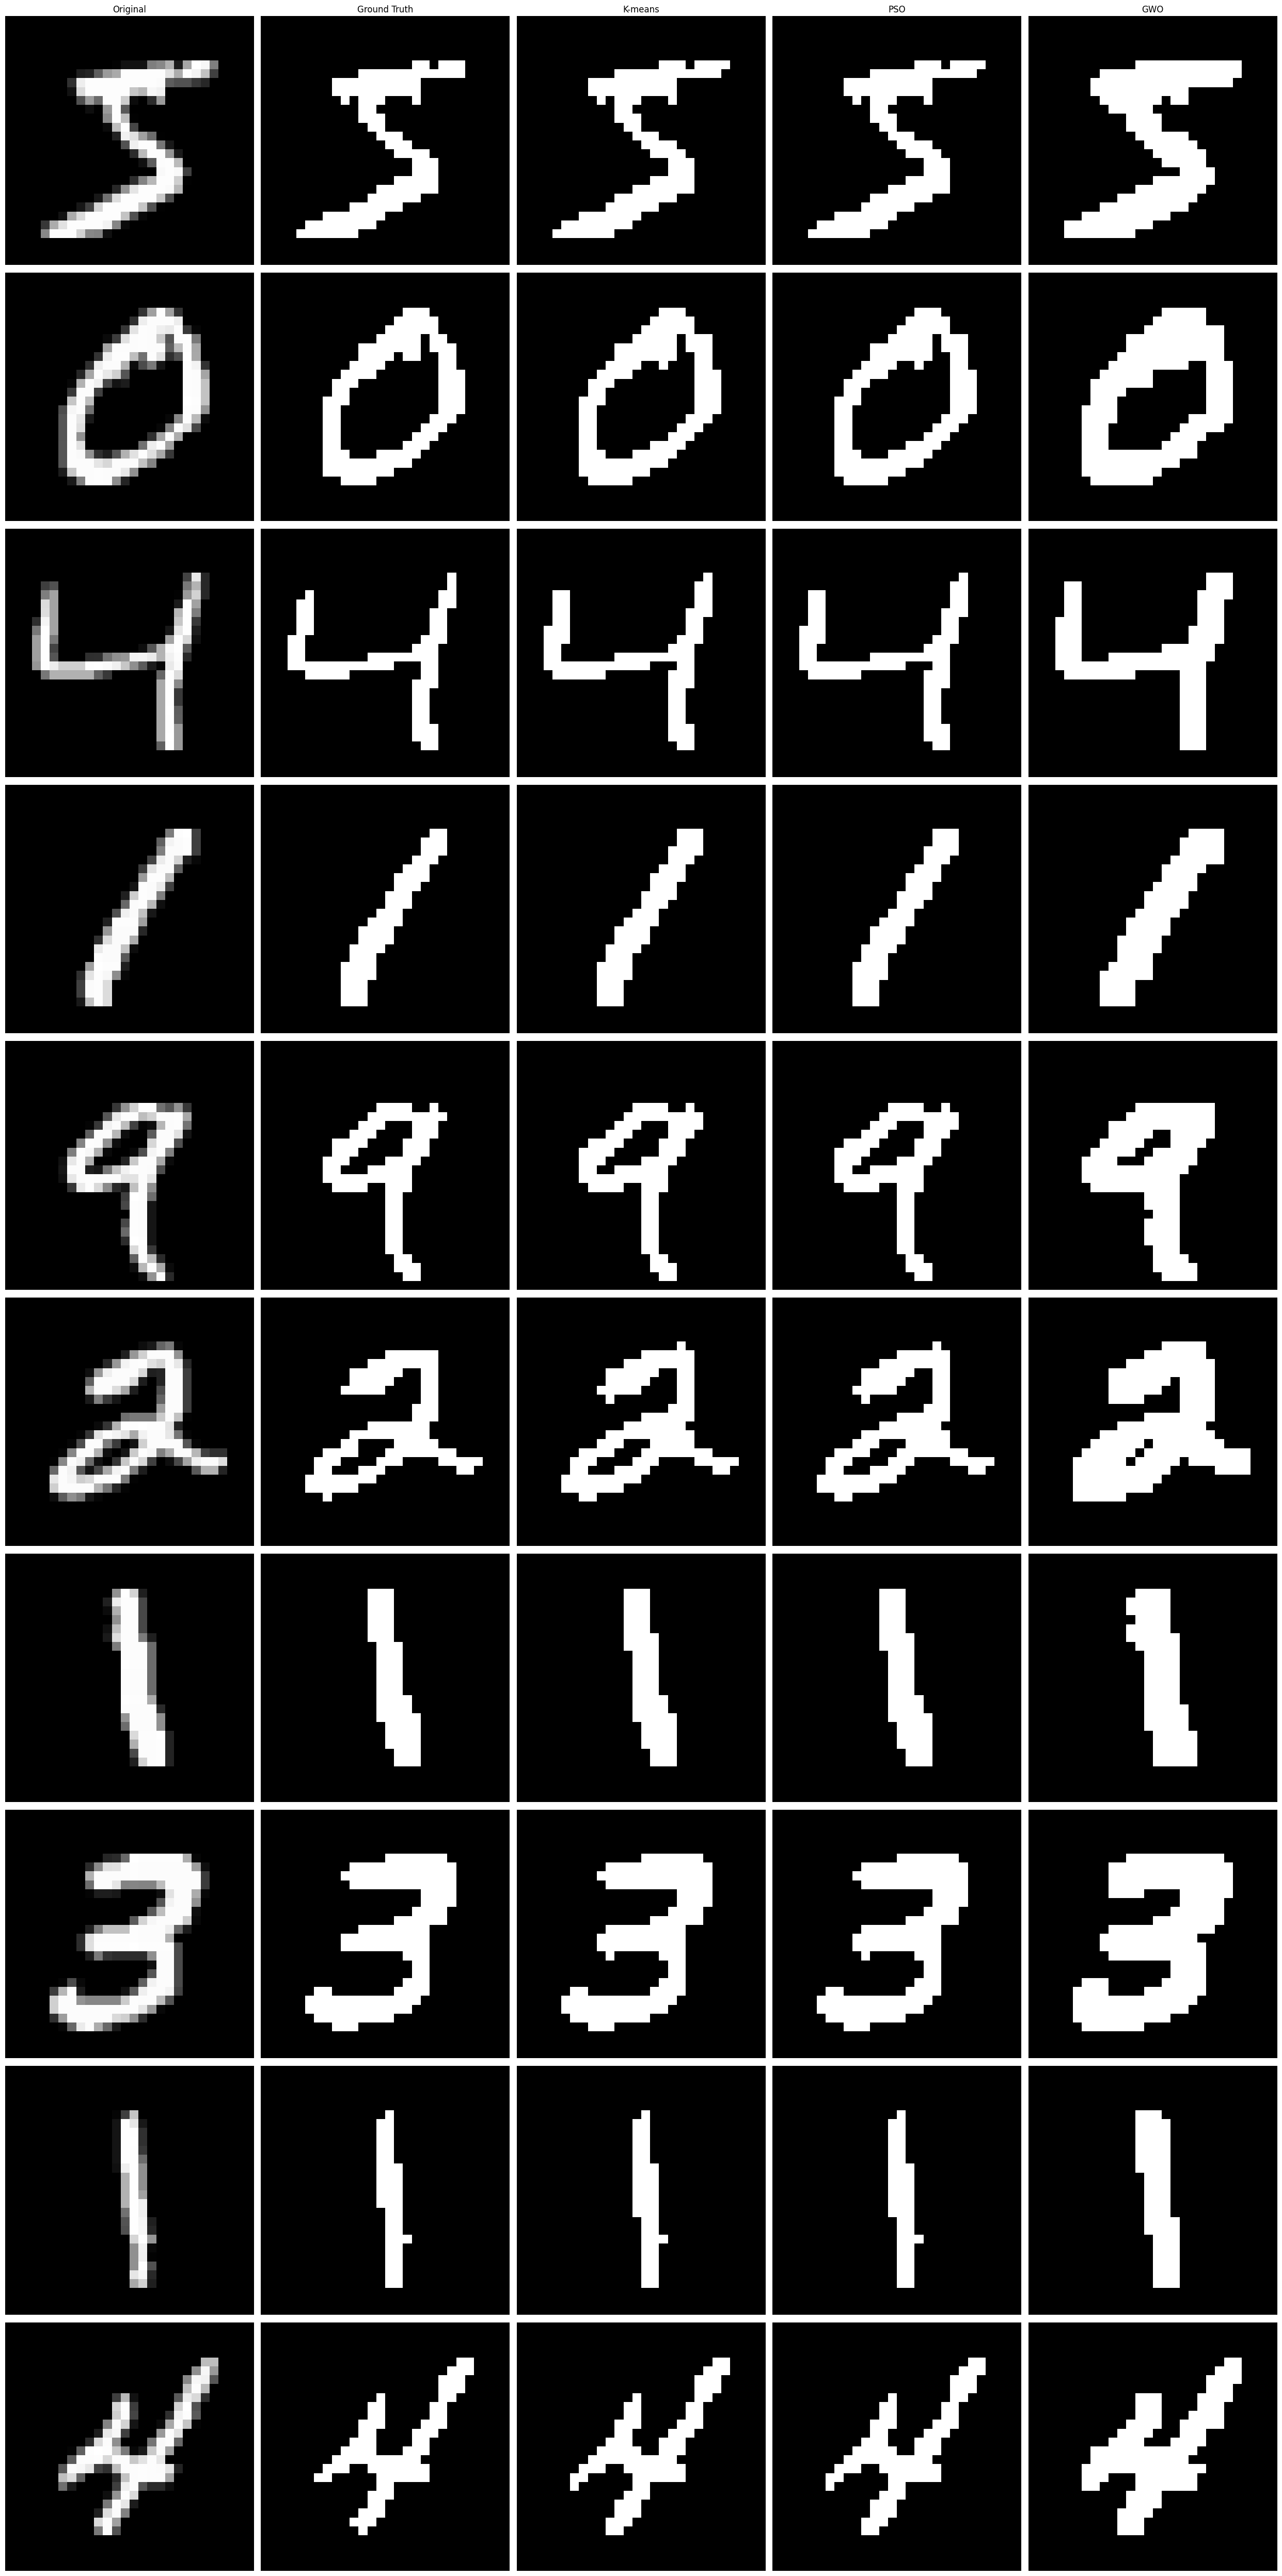

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.datasets import mnist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings("ignore")

class AdvancedOptimizer:
    """Base class for advanced swarm optimization techniques."""
    def __init__(
        self, 
        population_size: int = 30, 
        max_iterations: int = 100, 
        lower_bound: float = 0, 
        upper_bound: float = 255
    ):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        
        self.convergence_curve: List[float] = []
        self.best_threshold: float = 0
        self.best_fitness: float = float('inf')
    
    def calculate_segmentation_quality(
        self, 
        image: np.ndarray, 
        threshold: float
    ) -> float:
        """
        Calculate segmentation quality using multiple metrics.
        
        Args:
            image (np.ndarray): Input grayscale image
            threshold (float): Segmentation threshold
        
        Returns:
            float: Segmentation quality score (lower is better)
        """
        # Threshold the image
        binary_mask = (image > threshold).astype(np.uint8)
        
        # Histogram-based variance calculation
        hist = cv2.calcHist([image.astype(np.uint8)], [0], None, [256], [0, 256])
        hist_norm = hist.ravel() / hist.sum()
        
        # Background and foreground probabilities
        w0 = hist_norm[:int(threshold)+1].sum()
        w1 = 1.0 - w0
        
        if w0 == 0 or w1 == 0:
            return float('inf')
        
        # Mean calculations
        mu0 = np.sum(np.arange(int(threshold)+1) * hist_norm[:int(threshold)+1]) / w0
        mu1 = np.sum(np.arange(int(threshold)+1, 256) * hist_norm[int(threshold)+1:]) / w1
        
        # Between-class variance
        variance = w0 * w1 * ((mu0 - mu1) ** 2)
        
        # Additional penalty for imbalanced segmentation
        balance_penalty = abs(w0 - w1)
        
        return -variance + balance_penalty

class ParticleSwarmOptimization(AdvancedOptimizer):
    """Advanced Particle Swarm Optimization for image segmentation."""
    def __init__(
        self, 
        population_size: int = 30, 
        max_iterations: int = 100,
        cognitive_weight: float = 2.0,
        social_weight: float = 2.0
    ):
        super().__init__(population_size, max_iterations)
        self.cognitive_weight = cognitive_weight
        self.social_weight = social_weight
    
    def optimize(self, image: np.ndarray) -> Tuple[float, List[float]]:
        """
        Advanced PSO optimization for image segmentation.
        
        Args:
            image (np.ndarray): Input grayscale image
        
        Returns:
            Tuple of (best threshold, convergence history)
        """
        # Initialize particles
        positions = np.random.uniform(
            self.lower_bound, 
            self.upper_bound, 
            self.population_size
        )
        velocities = np.zeros_like(positions)
        
        # Personal best positions and fitness
        personal_best_positions = positions.copy()
        personal_best_fitness = np.array([
            self.calculate_segmentation_quality(image, pos) 
            for pos in positions
        ])
        
        # Global best tracking
        global_best_position = positions[
            np.argmin(personal_best_fitness)
        ]
        global_best_fitness = np.min(personal_best_fitness)
        
        # Convergence tracking
        self.convergence_curve = []
        
        # Constriction factor
        phi = self.cognitive_weight + self.social_weight
        chi = 2.0 / abs(2.0 - phi - np.sqrt(phi**2 - 4*phi))
        
        for iteration in range(self.max_iterations):
            # Adaptive inertia
            inertia = 0.9 - (0.9 - 0.4) * (iteration / self.max_iterations)
            
            # Random coefficients
            r1, r2 = np.random.rand(2)
            
            # Update velocities with constriction
            velocities = (
                chi * (
                    inertia * velocities + 
                    self.cognitive_weight * r1 * (
                        personal_best_positions - positions
                    ) + 
                    self.social_weight * r2 * (
                        global_best_position - positions
                    )
                )
            )
            
            # Update positions
            positions += velocities
            positions = np.clip(positions, self.lower_bound, self.upper_bound)
            
            # Evaluate fitness
            current_fitness = np.array([
                self.calculate_segmentation_quality(image, pos) 
                for pos in positions
            ])
            
            # Update personal best
            improved_indices = current_fitness < personal_best_fitness
            personal_best_positions[improved_indices] = positions[improved_indices]
            personal_best_fitness[improved_indices] = current_fitness[improved_indices]
            
            # Update global best
            min_fitness_index = np.argmin(current_fitness)
            if current_fitness[min_fitness_index] < global_best_fitness:
                global_best_position = positions[min_fitness_index]
                global_best_fitness = current_fitness[min_fitness_index]
            
            self.convergence_curve.append(global_best_fitness)
        
        self.best_threshold = global_best_position
        self.best_fitness = global_best_fitness
        
        return global_best_position, self.convergence_curve

class GreyWolfOptimization(AdvancedOptimizer):
    """Advanced Grey Wolf Optimization for image segmentation."""
    def optimize(self, image: np.ndarray) -> Tuple[float, List[float]]:
        """
        Advanced GWO optimization for image segmentation.
        
        Args:
            image (np.ndarray): Input grayscale image
        
        Returns:
            Tuple of (best threshold, convergence history)
        """
        # Initialize wolf positions
        wolves = np.random.uniform(
            self.lower_bound, 
            self.upper_bound, 
            self.population_size
        )
        
        # Fitness evaluation
        fitness = np.array([
            self.calculate_segmentation_quality(image, wolf) 
            for wolf in wolves
        ])
        
        # Sort wolves based on fitness
        sorted_indices = np.argsort(fitness)
        alpha = wolves[sorted_indices[0]]
        beta = wolves[sorted_indices[1]]
        delta = wolves[sorted_indices[2]]
        
        self.convergence_curve = []
        
        for iteration in range(self.max_iterations):
            # Adaptive coefficient
            a = 2.0 * (1.0 - iteration / self.max_iterations)
            
            for i in range(self.population_size):
                # Distance calculation
                D_alpha = abs(2.0 * np.random.rand() * alpha - wolves[i])
                D_beta = abs(2.0 * np.random.rand() * beta - wolves[i])
                D_delta = abs(2.0 * np.random.rand() * delta - wolves[i])
                
                # Position update
                X1 = alpha - a * D_alpha
                X2 = beta - a * D_beta
                X3 = delta - a * D_delta
                
                wolves[i] = (X1 + X2 + X3) / 3.0
            
            # Clip positions
            wolves = np.clip(wolves, self.lower_bound, self.upper_bound)
            
            # Re-evaluate fitness
            fitness = np.array([
                self.calculate_segmentation_quality(image, wolf) 
                for wolf in wolves
            ])
            
            # Update pack leadership
            sorted_indices = np.argsort(fitness)
            alpha = wolves[sorted_indices[0]]
            beta = wolves[sorted_indices[1]]
            delta = wolves[sorted_indices[2]]
            
            self.convergence_curve.append(fitness[sorted_indices[0]])
        
        self.best_threshold = alpha
        self.best_fitness = self.calculate_segmentation_quality(image, alpha)
        
        return alpha, self.convergence_curve

def perform_segmentation(
    image: np.ndarray, 
    method: str, 
    threshold: float = None
) -> np.ndarray:
    """
    Perform image segmentation using different methods.
    
    Args:
        image (np.ndarray): Input image
        method (str): Segmentation method ('kmeans', 'pso', 'gwo')
        threshold (float, optional): Threshold value for PSO/GWO
    
    Returns:
        np.ndarray: Segmented image
    """
    if method == 'kmeans':
        # Reshape image for K-means
        pixels = image.reshape(-1, 1)
        kmeans = KMeans(n_clusters=2, random_state=42).fit(pixels)
        segmented = kmeans.labels_.reshape(image.shape)
        
        # Ensure consistent labeling
        if np.mean(pixels[segmented.flatten() == 1]) < np.mean(pixels[segmented.flatten() == 0]):
            segmented = 1 - segmented
    
    elif method in ['pso', 'gwo']:
        # Threshold-based segmentation
        if threshold is None:
            raise ValueError(f"Threshold must be provided for {method.upper()} method")
        segmented = (image > threshold).astype(np.uint8)
    
    else:
        raise ValueError(f"Unknown segmentation method: {method}")
    
    return segmented

def dice_coefficient(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculate Dice coefficient for segmentation evaluation.
    
    Args:
        y_true (np.ndarray): Ground truth segmentation
        y_pred (np.ndarray): Predicted segmentation
    
    Returns:
        float: Dice coefficient
    """
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred))

def evaluate_segmentation(
    ground_truth: np.ndarray, 
    segmented: np.ndarray
) -> Dict[str, float]:
    """
    Evaluate segmentation performance.
    
    Args:
        ground_truth (np.ndarray): Ground truth segmentation
        segmented (np.ndarray): Predicted segmentation
    
    Returns:
        Dict of performance metrics
    """
    # Flatten arrays for metrics calculation
    gt_flat = ground_truth.flatten()
    seg_flat = segmented.flatten()
    
    # Performance metrics
    metrics = {
        'Adjusted Rand Index': adjusted_rand_score(gt_flat, seg_flat),
        'Normalized Mutual Info': normalized_mutual_info_score(gt_flat, seg_flat),
        'Dice Coefficient': dice_coefficient(ground_truth, segmented)
    }
    
    return metrics

def main():
    # Load MNIST dataset
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()
    
    # Combine a subset of train and test images
    images = np.vstack([train_images[:100], test_images[:100]])
    
    # Prepare ground truth (binary masks)
    ground_truth = (images > 128).astype(np.uint8)
    
    # Initialize optimizers
    pso = ParticleSwarmOptimization(population_size=30, max_iterations=50)
    gwo = GreyWolfOptimization(population_size=30, max_iterations=50)
    
    # Store results
    results = {
        'kmeans': {'metrics': [], 'segmentations': []},
        'pso': {'metrics': [], 'segmentations': [], 'thresholds': []},
        'gwo': {'metrics': [], 'segmentations': [], 'thresholds': []}
    }
    
    # Segmentation and evaluation
    for idx, image in enumerate(images):
        # K-means segmentation
        kmeans_seg = perform_segmentation(image, 'kmeans')
        results['kmeans']['segmentations'].append(kmeans_seg)
        results['kmeans']['metrics'].append(
            evaluate_segmentation(ground_truth[idx], kmeans_seg)
        )
        
        # PSO segmentation
        pso_threshold, _ = pso.optimize(image)
        pso_seg = perform_segmentation(image, 'pso', pso_threshold)
        results['pso']['segmentations'].append(pso_seg)
        results['pso']['thresholds'].append(pso_threshold)
        results['pso']['metrics'].append(
            evaluate_segmentation(ground_truth[idx], pso_seg)
        )
        
        # GWO segmentation
        gwo_threshold, _ = gwo.optimize(image)
        gwo_seg = perform_segmentation(image, 'gwo', gwo_threshold)
        results['gwo']['segmentations'].append(gwo_seg)
        results['gwo']['thresholds'].append(gwo_threshold)
        results['gwo']['metrics'].append(
            evaluate_segmentation(ground_truth[idx], gwo_seg)
        )
    
    # Aggregate performance
    print("Performance Metrics (Mean ± Std):")
    metrics_names = list(results['kmeans']['metrics'][0].keys())
    for metric in metrics_names:
        print(f"\n{metric}:")
        for method in ['kmeans', 'pso', 'gwo']:
            values = [m[metric] for m in results[method]['metrics']]
            print(f"{method.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")
    
    # Visualization
    plt.figure(figsize=(25, 50))  # Increased figure size for 10 rows

    # Create 10 example indices
    example_indices = range(10)  # First 10 examples
    methods = ['Original', 'Ground Truth', 'K-means', 'PSO', 'GWO']

    for row_idx, example_idx in enumerate(example_indices):
        # Get images for this example
        images_to_plot = [
            images[example_idx],
            ground_truth[example_idx],
            results['kmeans']['segmentations'][example_idx],
            results['pso']['segmentations'][example_idx],
            results['gwo']['segmentations'][example_idx]
        ]
        
        # Plot each method in a column
        for col_idx, (method, img) in enumerate(zip(methods, images_to_plot)):
            position = row_idx * len(methods) + col_idx + 1
            plt.subplot(len(example_indices), len(methods), position)
            plt.imshow(img, cmap='gray')
            
            # Only show titles on first row
            if row_idx == 0:
                plt.title(method)
                
            # Add example numbers on leftmost column
            if col_idx == 0:
                plt.ylabel(f"Ex {example_idx}", 
                          rotation=0, 
                          ha='right', 
                          va='center',
                          labelpad=30,
                          fontsize=12)
                
            plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()